In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
metadata = {
    "deoni": {
        "milk_yield": "8–12 L/day",
        "heat_tolerance": "High",
        "health": "Strong immunity, disease resistant",
        "health_condition": "Good",
        "appearance": "Black-white, medium body"
    },
    "gir": {
        "milk_yield": "12–20 L/day",
        "heat_tolerance": "Very High",
        "health": "Excellent immunity, highly adaptable",
        "health_condition": "Excellent",
        "appearance": "Red spotted, long ears"
    },
    "jersey": {
        "milk_yield": "15–25 L/day",
        "heat_tolerance": "Low",
        "health": "Sensitive to heat, requires care",
        "health_condition": "Average",
        "appearance": "Light brown, small body"
    },
    "khilari": {
        "milk_yield": "5–10 L/day",
        "heat_tolerance": "Very High",
        "health": "Strong, suitable for harsh climate",
        "health_condition": "Good",
        "appearance": "White/grey, long horns"
    },
    "murrah": {
        "milk_yield": "18–25 L/day",
        "heat_tolerance": "High",
        "health": "Very robust, high disease resistance",
        "health_condition": "Excellent",
        "appearance": "Jet black, spiral horns"
    },
    "nagpuri": {
        "milk_yield": "8–12 L/day",
        "heat_tolerance": "Very High",
        "health": "Hardy and drought resistant",
        "health_condition": "Good",
        "appearance": "Black, long face"
    },
    "pandharpuri": {
        "milk_yield": "6–10 L/day",
        "heat_tolerance": "Very High",
        "health": "Strong, survives in dry areas",
        "health_condition": "Good",
        "appearance": "Long horns backward"
    },
    "surti": {
        "milk_yield": "10–15 L/day",
        "heat_tolerance": "Moderate",
        "health": "Moderate resistance, needs care",
        "health_condition": "Average",
        "appearance": "Grey-black, sickle horns"
    }
}

In [4]:
from tensorflow.keras.models import load_model

animal_model = load_model("/content/drive/MyDrive/Animal_dataset/models/stage1_model.h5")
cow_model = load_model("/content/drive/MyDrive/cow_model.h5")
buffalo_model = load_model("/content/drive/MyDrive/buffalo_model.h5")

In [5]:
animal_classes = ['buffalo','cow','human','other']

cow_classes = ['Deoni','Gir','Jersey_Crossbred','Khillari']

buffalo_classes = ['Murrah','Nagpuri','Pandharpuri','Surti']

In [6]:
import cv2
import numpy as np
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

def preprocess(img_path):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (224,224))

    img = preprocess_input(img)   # MobileNetV2 preprocessing
    img = np.expand_dims(img, axis=0)

    return img

In [8]:
# Placeholder values for demonstration. In a real scenario, these would come from model predictions.
animal = 'cow'
animal_conf = 0.98
breed = 'gir' # Must be lowercase to match metadata keys
breed_conf = 0.95

info = metadata[breed]

result = {
    "animal": animal,
    "animal_confidence": round(animal_conf,2),
    "breed": breed,
    "breed_confidence": round(breed_conf,2),
    "milk_yield": info["milk_yield"],
    "heat_tolerance": info["heat_tolerance"],
    "health": info["health"],
    "health_condition": info["health_condition"],
    "appearance": info["appearance"]
}

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Saving image_23.jpg to image_23.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


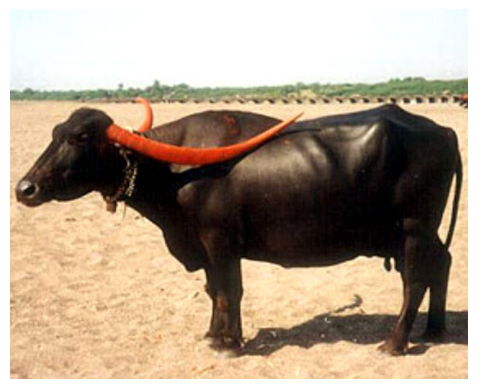


========== FINAL RESULT ==========

Animal            : buffalo
Confidence        : 98.24 %

Breed             : pandharpuri
Breed Confidence  : 91.69 %

Milk Yield        : 6–10 L/day
Heat Tolerance    : Very High
Health            : Strong in dry regions
Health Condition  : Good
Appearance        : Very long backward horns




In [18]:
# ============================================================
# STEP 1 — MOUNT GOOGLE DRIVE
# ============================================================
from google.colab import drive
drive.mount('/content/drive')


# ============================================================
# STEP 2 — IMPORT LIBRARIES
# ============================================================
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from google.colab import files


# ============================================================
# STEP 3 — LOAD MODELS
# ============================================================
animal_model = load_model("/content/drive/MyDrive/Animal_dataset/models/stage1_model.h5")
cow_model = load_model("/content/drive/MyDrive/cow_model.h5")
buffalo_model = load_model("/content/drive/MyDrive/buffalo_model.h5")


# ============================================================
# STEP 4 — CLASS LABELS
# ============================================================
animal_classes = ['buffalo', 'cow', 'human', 'other']
cow_classes = ['deoni', 'gir', 'jersey', 'khilari']
buffalo_classes = ['murrah', 'nagpuri', 'pandharpuri', 'surti']


# ============================================================
# STEP 5 — METADATA (ALL BREEDS)
# ============================================================
metadata = {
    "deoni": {
        "milk_yield": "8–12 L/day",
        "heat_tolerance": "High",
        "health": "Strong immunity, disease resistant",
        "health_condition": "Good",
        "appearance": "Black-white, medium body"
    },
    "gir": {
        "milk_yield": "12–20 L/day",
        "heat_tolerance": "Very High",
        "health": "Excellent immunity, highly adaptable",
        "health_condition": "Excellent",
        "appearance": "Red spotted, long ears"
    },
    "jersey": {
        "milk_yield": "15–25 L/day",
        "heat_tolerance": "Low",
        "health": "Sensitive to heat, needs care",
        "health_condition": "Average",
        "appearance": "Light brown, small body"
    },
    "khilari": {
        "milk_yield": "5–10 L/day",
        "heat_tolerance": "Very High",
        "health": "Strong, suitable for harsh climate",
        "health_condition": "Good",
        "appearance": "White/grey, long horns"
    },
    "murrah": {
        "milk_yield": "18–25 L/day",
        "heat_tolerance": "High",
        "health": "Very robust, high resistance",
        "health_condition": "Excellent",
        "appearance": "Jet black, spiral horns"
    },
    "nagpuri": {
        "milk_yield": "8–12 L/day",
        "heat_tolerance": "Very High",
        "health": "Hardy, drought resistant",
        "health_condition": "Good",
        "appearance": "Black, long face"
    },
    "pandharpuri": {
        "milk_yield": "6–10 L/day",
        "heat_tolerance": "Very High",
        "health": "Strong in dry regions",
        "health_condition": "Good",
        "appearance": "Very long backward horns"
    },
    "surti": {
        "milk_yield": "10–15 L/day",
        "heat_tolerance": "Moderate",
        "health": "Needs moderate care",
        "health_condition": "Average",
        "appearance": "Grey-black, sickle horns"
    }
}


# ============================================================
# STEP 6 — IMAGE PREPROCESS FUNCTION
# ============================================================
def preprocess(img_path):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (224,224))
    img = preprocess_input(img)
    img = np.expand_dims(img, axis=0)
    return img


# ============================================================
# STEP 7 — FINAL PREDICTION FUNCTION
# ============================================================
def final_predict(img_path):

    img = preprocess(img_path)

    # ---------- STAGE 1 ----------
    animal_pred = animal_model.predict(img)
    animal_idx = np.argmax(animal_pred)

    animal = animal_classes[animal_idx]
    animal_conf = round(float(np.max(animal_pred) * 100), 2)

    breed = "N/A"
    breed_conf = 0
    info = None

    # ---------- STAGE 2 ----------
    if animal == 'cow':
        breed_pred = cow_model.predict(img)
        breed_idx = np.argmax(breed_pred)

        raw = cow_classes[breed_idx]
        breed = 'jersey' if raw == 'Jersey_Crossbred' else raw.lower()

        breed_conf = round(float(np.max(breed_pred) * 100), 2)
        info = metadata.get(breed)

    elif animal == 'buffalo':
        breed_pred = buffalo_model.predict(img)
        breed_idx = np.argmax(breed_pred)

        breed = buffalo_classes[breed_idx].lower()
        breed_conf = round(float(np.max(breed_pred) * 100), 2)
        info = metadata.get(breed)

    # ---------- RESULT ----------
    result = {
        "animal": animal,
        "animal_confidence": f"{animal_conf} %",
        "breed": breed,
        "breed_confidence": f"{breed_conf} %",
        "milk_yield": info.get("milk_yield", "N/A") if info else "N/A",
        "heat_tolerance": info.get("heat_tolerance", "N/A") if info else "N/A",
        "health": info.get("health", "N/A") if info else "N/A",
        "health_condition": info.get("health_condition", "N/A") if info else "N/A",
        "appearance": info.get("appearance", "N/A") if info else "N/A"
    }

    return result


# ============================================================
# STEP 8 — TEST WITH IMAGE
# ============================================================
uploaded = files.upload()
img_name = list(uploaded.keys())[0]

result = final_predict(img_name)

# Show image
img = cv2.imread(img_name)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.axis('off')
plt.show()


# ============================================================
# STEP 9 — CLEAN OUTPUT DISPLAY
# ============================================================
print("\n========== FINAL RESULT ==========\n")

print(f"Animal            : {result['animal']}")
print(f"Confidence        : {result['animal_confidence']}\n")

print(f"Breed             : {result['breed']}")
print(f"Breed Confidence  : {result['breed_confidence']}\n")

print(f"Milk Yield        : {result['milk_yield']}")
print(f"Heat Tolerance    : {result['heat_tolerance']}")
print(f"Health            : {result['health']}")
print(f"Health Condition  : {result['health_condition']}")
print(f"Appearance        : {result['appearance']}")

print("\n=================================\n")